In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con

In [2]:
from helper import *

In [3]:
def jacobianClosed(v, Phi, rhat = np.array([1, 0, 0])):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    v = np.asarray(v, dtype=float)
    v2 = speed(v)
    u = np.sqrt(v2**2 - 2*Phi)
    vdotr = speed(v * rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)

(1e-18, 1.0)

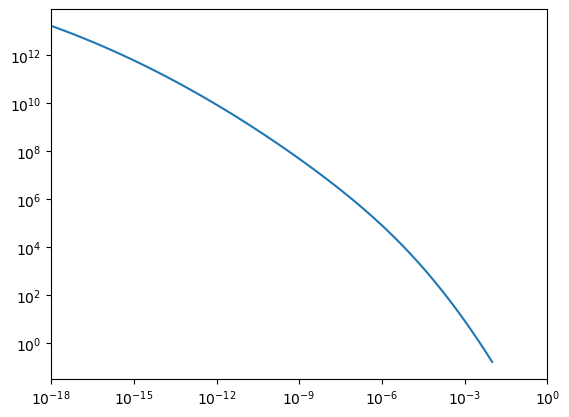

In [4]:
rho = np.logspace(-18, -2, 100)

plt.clf()
plt.loglog(rho, numStreams(rho))
plt.xlim((1e-18, 1e-0))




In [5]:
v_c = np.array([218, -119, 21])

num = 1000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167**2]*3), num)
#spd = speed(vel)

vel += v_c #solar frame vel at asymptotic infinity

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))



In [36]:
import astropy.constants as acon

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def v_inf(v, t):
    r = np.array([[np.cos(t), np.sin(t), 0]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

def func(v, vi, t):
    return (v_inf(v, t) - vi).T[:, 0]

v = []
t = 0
for vi in vel:
    root = fsolve(func, [-25,-25, -25], args=(vi, t))
    v.append(root)
v = np.array(v)



/tmp/ipykernel_58537/36039715.py:8: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_58537/36039715.py:24: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-25,-25, -25], args=(vi, t))


In [37]:
Phi = 887.13
new_dens = rho / jacobianClosed(v, Phi)

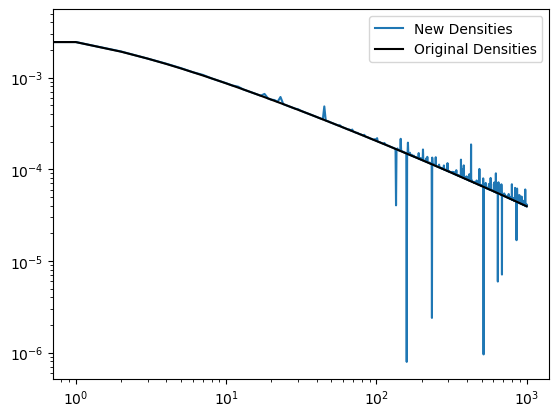

In [38]:
plt.clf()
#plt.scatter(np.arange(0, num, 1),new_dens, label ="New Densities", s = 3)
plt.plot(new_dens, label ="New Densities")

plt.loglog(rho, label="Original Densities", c="black")
plt.legend()

/tmp/ipykernel_58537/36039715.py:8: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_58537/1273198626.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [-25,-25, -25], args=(vi, t))
/tmp/ipykernel_58537/1273198626.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  root = fsolve(func, [-25,-25, -25], args=(vi, t))


<Figure size 640x480 with 0 Axes>

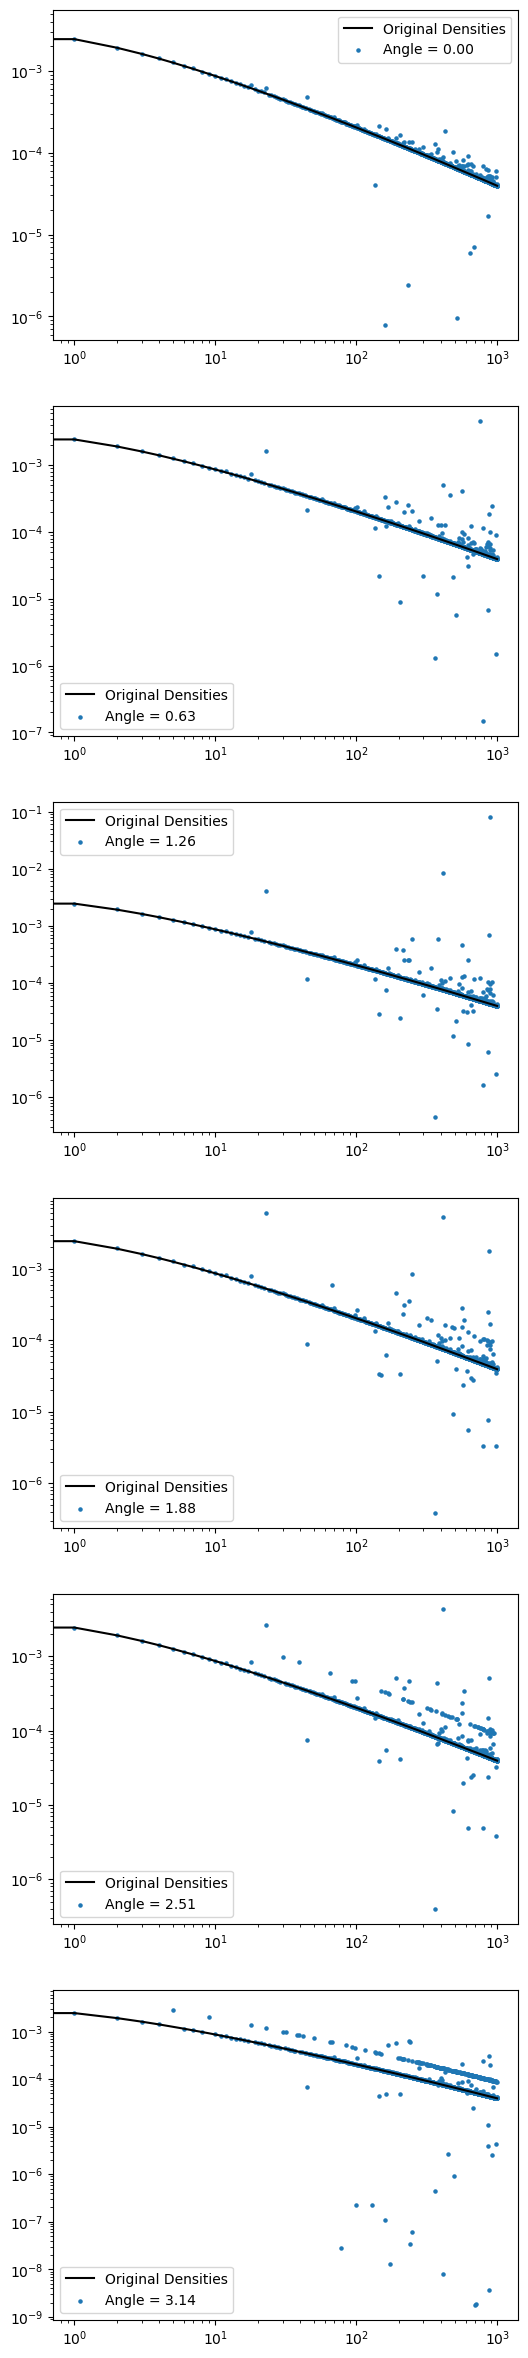

In [47]:
def func(v, vi, t):
    return (v_inf(v, t) - vi).T[:, 0]

Phi = 887.13

plt.clf()

num_angles = 6
fig, ax = plt.subplots(num_angles, 1, figsize=(6, 5 * num_angles))


i = 0
for t in np.linspace(0, np.pi, num_angles):
    axe = ax[i]
    axe.loglog(rho, label="Original Densities", c="black")
    v = []
    for vi in vel:
        root = fsolve(func, [-25,-25, -25], args=(vi, t))
        v.append(root)
    v = np.array(v)

    new_dens = rho / jacobianClosed(v, Phi)
    axe.scatter(np.arange(0, num, 1), new_dens, label =f"Angle = {t:.2f}", s = 5)
    #plt.plot(new_dens, label ="New Densities")
    axe.legend()
    i += 1




In [ ]:
# Plot histograms of this density distribution, before and after. Use log scaling to see the differences.

In [162]:
((new_dens - rho) / rho).max()

1.523029527975757

In [161]:
new_dens[426], rho[426]

(0.0001865542310785314, 7.39405658990464e-05)

In [160]:
v[426], vel[426]

(array([-20.88690165, -45.73658892,  10.83200306]),
 array([ -2.0587963 , -28.65162727,   6.78569438]))

In [151]:
co = v[426][0] / np.linalg.norm(v[426])
np.arccos(- co)

1.152621404201767

In [158]:
sumnew = new_dens.sum()
sumold = sum(rho)

(sumnew - sumold) / sumold

0.008976244773534895